# Day-05: Making Seismic Wavelets with Bruges

On **Day-05** of my **100 Days of Python for Oil & Gas Subsurface Analytics** journey, I explored how to generate **seismic wavelets using the Bruges Python library**.

Wavelets are fundamental in **seismic modeling and interpretation** because they represent the seismic source signature used to simulate reflections from subsurface layers.

The **Bruges library** provides implementations of several commonly used seismic wavelets used in geophysical analysis and forward modeling.

---

# Available Wavelets in Bruges

Bruges includes implementations of several widely used seismic wavelets:

- **Ricker Wavelet** – The most commonly used seismic wavelet.
- **Ormsby Wavelet** – Defined by four frequencies (band-limited wavelet).
- **Klauder Wavelet** – Often used for **vibroseis sweep simulations**.
- **Berlage Wavelet** – Suitable for **marine seismic airgun sources**.
- **Sinc Wavelet** – Useful for theoretical signal analysis.
- **Gabor Wavelet** – Combines Gaussian envelope with sinusoidal carrier.
- **Gaussian Wavelet** – Smooth pulse with Gaussian shape.

These wavelets are widely used in **seismic forward modeling, inversion, and synthetic seismogram generation**.

---

# Key Features of Bruges Wavelets

All wavelets implemented in Bruges share several useful features:

### 1. Return Format
Each wavelet function returns a **tuple containing two arrays**:

- Wavelet amplitude values
- Corresponding time samples

```python
wavelet, time = function(...)


## 🗂️ Available Wavelets

```
bruges.filters
├── 🏔️  Ricker      — Mexican Hat; defined by central frequency
├── 🌐  Ormsby       — Trapezoidal bandwidth; time & frequency implementations
├── 📡  Klauder      — Sweep/chirp; ideal for Vibroseis modeling
├── 🌊  Berlage      — Causal; ideal for airgun marine seismic
├── 〰️  Sinc         — Ideal band-limited; theoretical reference
├── 🔔  Gabor        — Gaussian-modulated sinusoid; time-frequency localized
└── 📈  Gaussian     — Smooth envelope; derivative orders supported
```

---

## 🏔️ Ricker Wavelet

> **Also known as:** Mexican Hat wavelet  
> **Best for:** General-purpose synthetic seismograms, zero-phase modeling

The Ricker is the **simplest and most commonly used** wavelet in seismic processing. It is fully described by a single, intuitive parameter — its **central (dominant) frequency**.

### Parameters

| Parameter | Description | Example |
|---|---|---|
| `duration` | Total length of pulse (seconds) | `0.128` → 128 ms long |
| `dt` | Sample interval (seconds) | `0.004` → 250 Hz sample rate |
| `f` | Dominant frequency (Hz) | `25` → low-frequency pulse |


---

## 🌐 Ormsby Wavelet

> **Defined by:** Four corner frequencies `[f1, f2, f3, f4]`  
> **Best for:** Band-limited wavelets with a trapezoidal spectrum

```python
# Ormsby: defined by 4 frequencies [low-cut, low-pass, high-pass, high-cut]
wavelet, t = bruges.filters.ormsby(
    duration=0.128,
    dt=0.004,
    f=[5, 10, 60, 80]           # trapezoidal passband
)
```

> ⚠️ **Two implementations available:**
> - `ormsby()` — time-domain construction  
> - `ormsby_fft()` — frequency-domain construction (slightly different edge behavior)

---

## 📡 Klauder Wavelet *(Vibroseis Sweep)*

> **Also known as:** Chirp or sweep wavelet  
> **Best for:** Vibroseis / land seismic modeling

```python
# Klauder: autocorrelation of a linear frequency sweep
wavelet, t = bruges.filters.klauder(
    duration=0.128,
    dt=0.004,
    f=[10, 80],                 # sweep from 10 → 80 Hz
    autocorrelate=True
)
```

---

## 🌊 Berlage Wavelet *(Marine Airgun)*

> **Causal wavelet** — starts at zero and decays  
> **Best for:** Marine seismic, airgun source simulation

```python
# Berlage: exponentially modulated; physically realistic for airgun
wavelet, t = bruges.filters.berlage(
    duration=0.128,
    dt=0.004,
    f=25,
    n=2,                        # order of derivative
    alpha=180,                  # decay rate
    phi=-np.pi/2               # phase rotation
)
```

---

## 〰️ Sinc Wavelet

> **Ideal brick-wall bandpass** — theoretical reference wavelet

```python
wavelet, t = bruges.filters.sinc(
    duration=0.128,
    dt=0.004,
    f=25                        # cutoff frequency
)
```

---

## 🔔 Gabor Wavelet

> **Gaussian-modulated sinusoid** — optimal time-frequency localization

```python
wavelet, t = bruges.filters.gabor(
    duration=0.128,
    dt=0.004,
    f=25,                       # central frequency
    sigma=0.015                 # Gaussian window width (seconds)
)
```

---

## 📈 Gaussian Wavelet

> **Smooth, derivative-based** — useful for AVO and attribute analysis

```python
wavelet, t = bruges.filters.gaussian(
    duration=0.128,
    dt=0.004,
    f=25,
    order=1                     # 0=Gaussian, 1=1st derivative, 2=2nd derivative
)

---

## 💡 Key Concepts Cheatsheet

```
┌─────────────────────────────────────────────────────────┐
│  bruges.filters wavelet rules                           │
├─────────────────────────────────────────────────────────┤
│  ✅  Always returns (amplitudes, time) tuple            │
│  ✅  Always odd-length                                  │
│  ✅  Pass t=array for custom time sampling              │
│  ✅  Pass f=array for a 2D wavelet bank                 │
│  ✅  f is 2D array for Ormsby & Klauder banks           │
└─────────────────────────────────────────────────────────┘
```

| Wavelet | Phase | Causal | Best Application |
|---|---|---|---|
| **Ricker** | Zero | ✗ | General synthetics |
| **Ormsby** | Zero | ✗ | Band-limited synthetics |
| **Klauder** | Zero | ✗ | Vibroseis land seismic |
| **Berlage** | Mixed | ✅ | Marine airgun |
| **Sinc** | Zero | ✗ | Theoretical reference |
| **Gabor** | Mixed | ✗ | Time-frequency analysis |
| **Gaussian** | Zero | ✗ | AVO / attribute analysis |

---

## 📚 Resources

- 📖 [Bruges Documentation](https://bruges.readthedocs.io)
- 🐍 [Bruges GitHub](https://github.com/agile-geoscience/bruges)
- 📊 [SEG Wiki — Wavelets](https://wiki.seg.org/wiki/Dictionary:Wavelet)

---

*Day 05 of the Seismic Processing with Python series · bruges `v0.5+`*

Wavelet length : 33 samples
Time axis      : -64.0 ms  →  64.0 ms
Peak amplitude : 1.0000


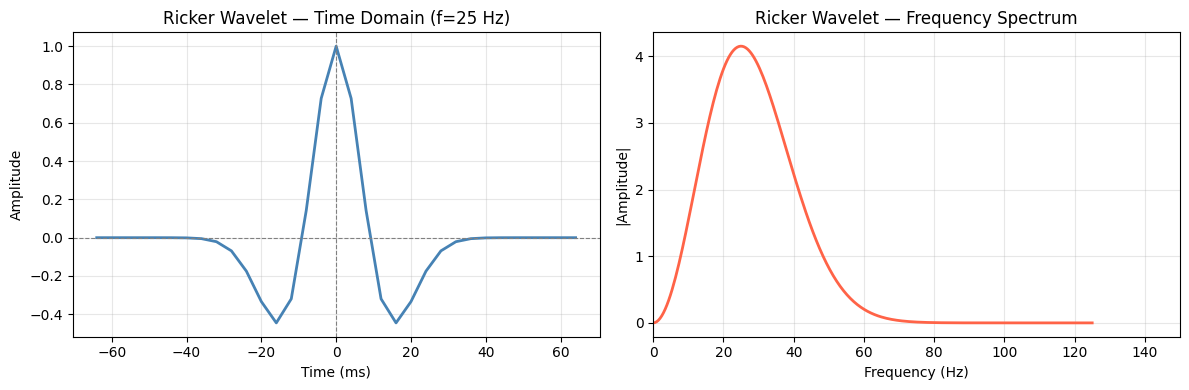

In [1]:

import bruges
import numpy as np
import matplotlib.pyplot as plt

# 🎯 Simple Ricker: 128ms long, 4ms sample rate, 25 Hz
wavelet, t = bruges.filters.ricker(
    duration=0.128,   # 128 ms total length
    dt=0.004,         # 4 ms sample interval (250 Hz)
    f=25              # 25 Hz dominant frequency
)

print(f"Wavelet length : {len(wavelet)} samples")
print(f"Time axis      : {t[0]*1000:.1f} ms  →  {t[-1]*1000:.1f} ms")
print(f"Peak amplitude : {wavelet.max():.4f}")

""" 
Wavelet length : 33 samples       ← always odd!
Time axis      : -64.0 ms  →  64.0 ms
Peak amplitude : 1.0000
"""

### Plot It

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Time domain ---
axes[0].plot(t * 1000, wavelet, color='steelblue', lw=2)
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].axvline(0, color='gray', lw=0.8, ls='--')
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Ricker Wavelet — Time Domain (f=25 Hz)")
axes[0].grid(True, alpha=0.3)

# --- Amplitude spectrum ---
W = np.fft.rfft(wavelet, n=512)
freqs = np.fft.rfftfreq(512, d=0.004)
axes[1].plot(freqs, np.abs(W), color='tomato', lw=2)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("|Amplitude|")
axes[1].set_title("Ricker Wavelet — Frequency Spectrum")
axes[1].set_xlim(0, 150)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ricker_wavelet.png", dpi=150)
plt.show()



## A bank of ricker

In [12]:
freq=np.arange(4,50,2)
print(freq)

[ 4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48]


In [19]:
import bruges as bg 
wavelet,t= bg.filters.ricker(duration=0.096,dt=0.001,f=freq)
wavelet.shape

(23, 97)

Text(0.5, 1.0, 'Ricker wavelet')

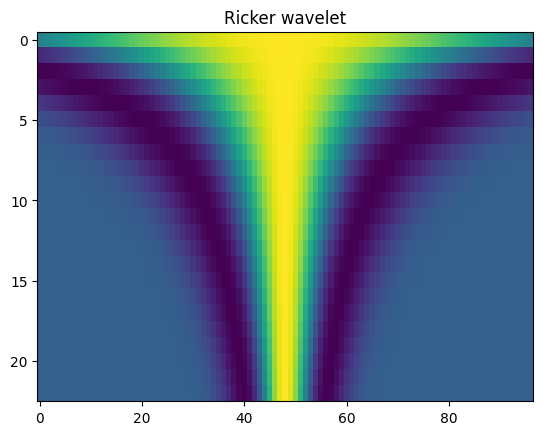

In [23]:
plt.imshow(wavelet,aspect="auto")

plt.title("Ricker wavelet")

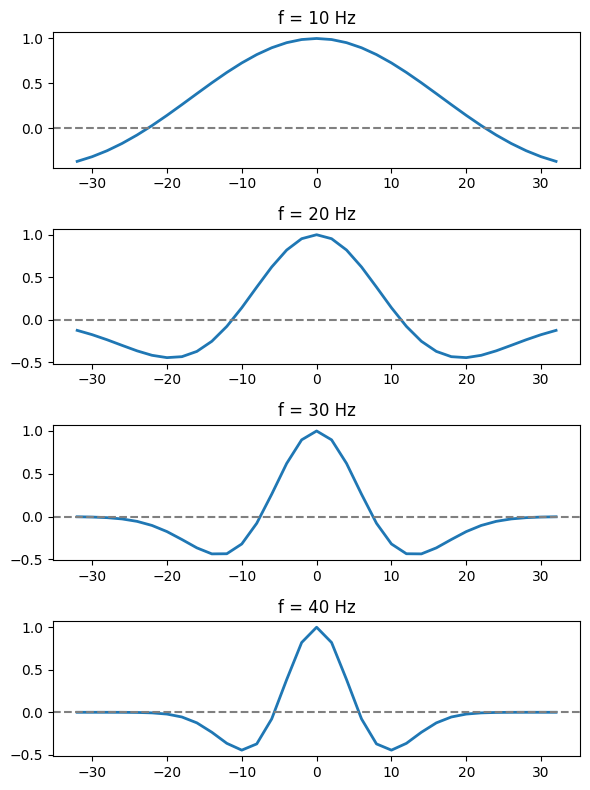

In [39]:
import bruges as bg
import matplotlib.pyplot as plt

freqs = [10,20,30,40]

bank, t = bg.filters.ricker(duration=0.064, dt=0.002, f=freqs)

fig, axes = plt.subplots(4,1, figsize=(6,8))

for i, ax in enumerate(axes):
    ax.plot(t*1000, bank[i], lw=2)
    ax.axhline(0, color='gray', ls='--')
    ax.set_title(f"f = {freqs[i]} Hz")

plt.tight_layout()
plt.show()

In [38]:
print(bank.shape)
print(len(t))

(4, 33)
33


Text(0.5, 1.0, 'Bank of Ricker Wavelet')

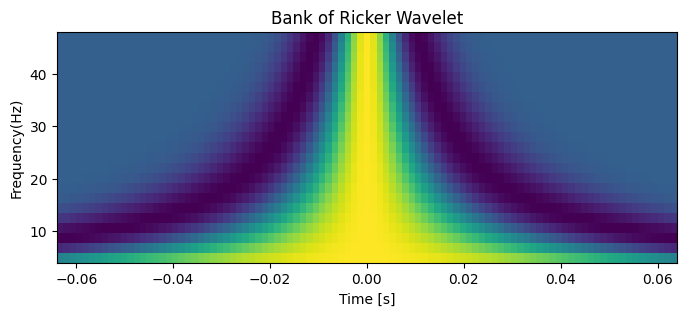

In [36]:
extent = [t[0], t[-1], freqs[0], freqs[-1]]
fig,ax=plt.subplots(figsize=(8,3))
ax.imshow(wavelet,extent=extent,aspect='auto',origin='lower')
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency(Hz)")
ax.set_title("Bank of Ricker Wavelet")


# Ormsby wavelet

In [42]:
w_ormsby,t=bg.filters.ormsby(
    duration=0.4,
    dt=0.001,
    f=[4,8,45,80]
)
w_ormsby.shape

(401,)

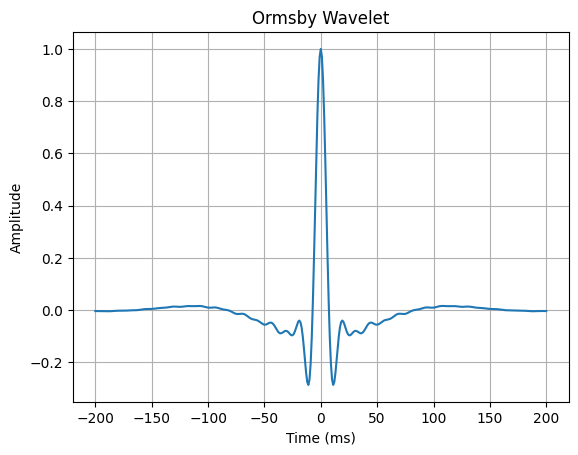

In [ ]:

plt.plot(t*1000, w_ormsby)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Ormsby Wavelet")
plt.grid()
plt.show()

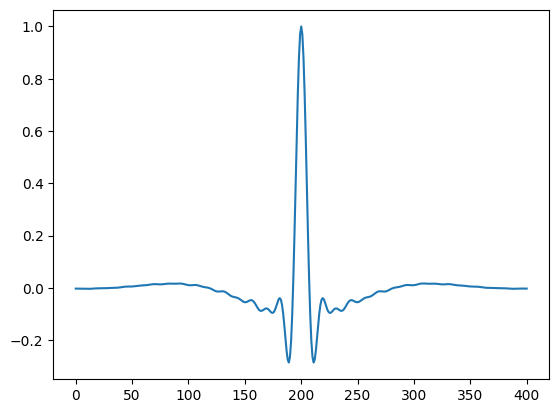

In [46]:
plt.plot(w_ormsby)

# Ormsby FFT
It allows us define a different shape. Instead of the spectrum having a flat top, you can give it ‘colour’ (more or lower or higher frequencies) by providing two extra values for the power of the f2 and f3 frequencies, given in relative dB

In [48]:
w_ormsby_fft,t=bg.filters.ormsby_fft(
    duration=0.400,
    dt=0.001,
    f=[4,8,45,60],
    P=[0,-15]
)
w_ormsby_fft.shape

(401,)

Text(0.5, 1.0, 'Ormbsy fileter')

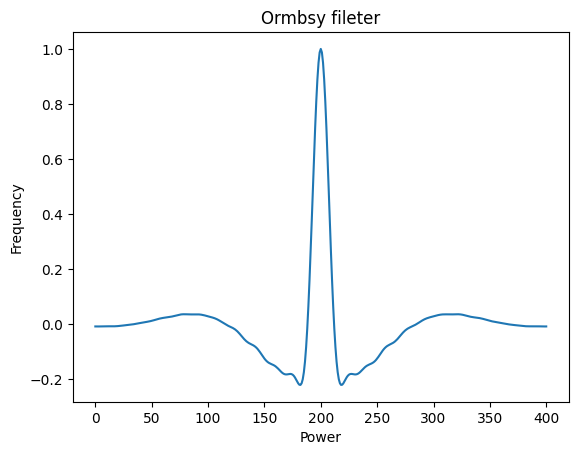

In [55]:
plt.plot(w_ormsby_fft)
plt.xlabel("Power")
plt.ylabel("Frequency")
plt.title("Ormbsy fileter")

# Klauder wavelet

A Klauder wavelet is a seismic wavelet obtained by autocorrelating a linear frequency sweep (chirp).

It is widely used in vibroseis acquisition where the source sends a frequency sweep instead of an impulse.



---

## Workflow in vibroseis

-    Sweep signal  →  recorded data  →  correlate with sweep  →  Klauder wavelet


If the sweep signal is:

\[
s(t)
\] then the **Klauder wavelet** is defined as the autocorrelation of the sweep signal:

\[
K(t) = s(t) * s(-t)
\]

where:

- \(K(t)\) = Klauder wavelet  
- \(s(t)\) = sweep signal  
- \(*\) = convolution operator

---

In [58]:
w_klouder,t=bg.filters.klauder(
    duration=0.500,
    dt=0.001,
    f=[10,80]
)
w_klouder.shape

(501,)

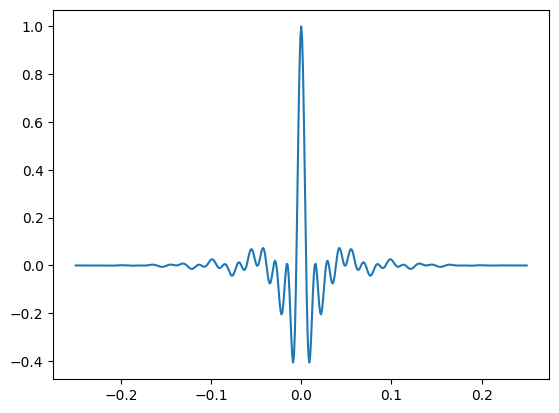

In [60]:
plt.plot(t,w_klouder)

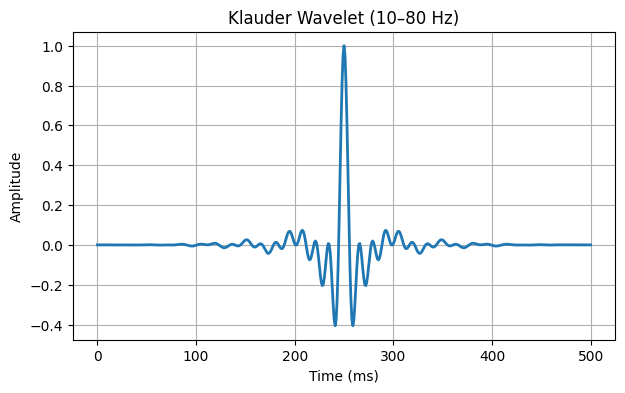

In [62]:
# Plot
plt.figure(figsize=(7,4))
plt.plot(w_klouder,lw=2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Klauder Wavelet (10–80 Hz)")
plt.grid()

plt.show()

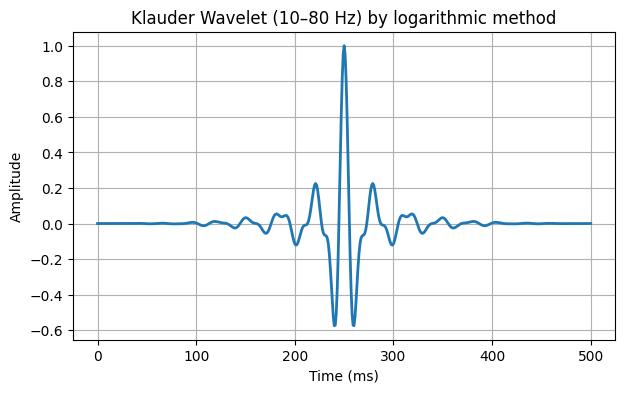

In [64]:
w_klouder_log,t=bg.filters.klauder(
    duration=0.500,
    dt=0.001,
    f=[10,80],
    method="logarithmic"
)
# Plot
plt.figure(figsize=(7,4))
plt.plot(w_klouder_log,lw=2)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Klauder Wavelet (10–80 Hz) by logarithmic method")
plt.grid()

plt.show()

## Berlage Wavelet

The **Berlage wavelet** is a causal seismic wavelet used to represent realistic seismic source signatures.

Unlike symmetric wavelets (like Ricker), the Berlage wavelet is asymmetric and decays exponentially, which better mimics actual seismic source behavior.

It consists of a **sinusoidal oscillation modulated by an exponential decay envelope**.

---

## Mathematical Formulation

The Berlage wavelet is defined as:

$$
B(t) = A \, t^{n} e^{-\alpha t} \cos(2\pi f t + \phi), \quad t \ge 0
$$
where:

- $B(t)$ — Berlage wavelet amplitude  
- $A$ — amplitude scaling factor  
- $t$ — time  
- $n$ — build-up parameter  
- $\alpha$ — exponential decay constant  
- $f$ — dominant frequency  
- $\phi$ — phase shift
---

## Characteristics

- **Asymmetric waveform**
- Models **marine airgun seismic sources**
- Includes **exponential decay**
- More realistic than symmetric wavelets for some seismic acquisition systems

---



In [66]:
w_berlage,t=bg.filters.berlage(
    duration=0.400,
    dt=0.001,
    f=25
)
w_berlage.shape

(401,)

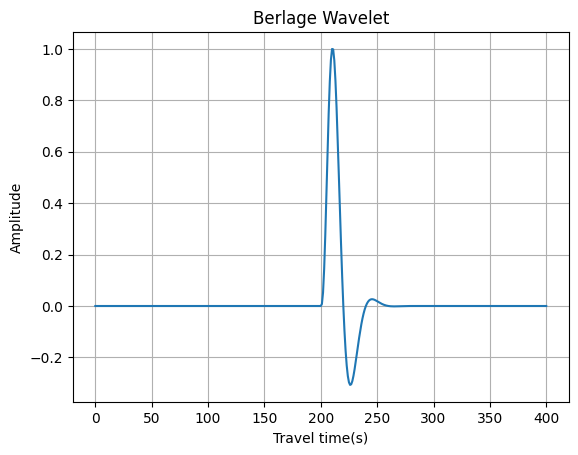

In [72]:
plt.plot(w_berlage)
plt.xlabel("Travel time(s)")
plt.ylabel("Amplitude")
plt.title("Berlage Wavelet")
plt.grid()



## Generalized Seismic Wavelet
It is a parametric wavelet family used in seismic modelling where a parameter controls the shape and symmetry of the wavelet.

Instead of using a fixed wavelet like the **Ricker wavelet**, a **generalized wavelet** allows you to generate different wavelet shapes using a single mathematical expression.

This approach is useful for:

- Seismic forward modeling  
- Wavelet estimation  
- Inversion studies  
- Testing sensitivity of synthetic seismograms  

---

## Mathematical Idea

A common generalized seismic wavelet form is:

$$
w(t) = A\, t^{n} e^{-\alpha t} \cos(2\pi f t + \phi)
$$

---

### Parameters

| Parameter | Meaning |
|----------|--------|
| $A$ | Amplitude |
| $t$ | Time |
| $n$ | Shape parameter |
| $\alpha$ | Decay constant |
| $f$ | Dominant frequency |
| $\phi$ | Phase |

---

### Role of the Shape Parameter

The **shape parameter $n$** controls the wavelet family.

Changing $n$ can produce different types of wavelets such as:

- **Berlage-like wavelets**
- **Asymmetric wavelets**
- **Symmetric approximations**

---

## Why It Is Used in Geophysics

In real seismic data:

- Source signatures vary between surveys  
- Earth filtering modifies the wavelet shape  
- Seismic signals are often **not zero-phase**

Using a **generalized wavelet** allows flexible modeling of these real-world effects, making it useful for **synthetic modeling, inversion studies, and wavelet estimation**.

In [73]:
w_generalise,t=bg.filters.generalized(
    duration=0.096,
    dt=0.001,
    f=25
)
w_generalise.shape

(97,)

Text(0.5, 1.0, 'Generalized Wavelet')

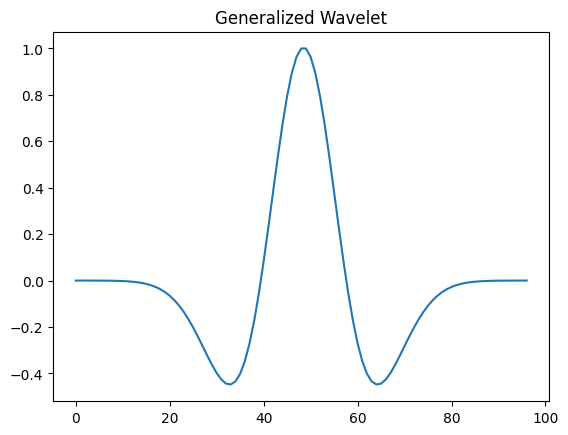

In [74]:
plt.plot(w_generalise)
plt.title("Generalized Wavelet")

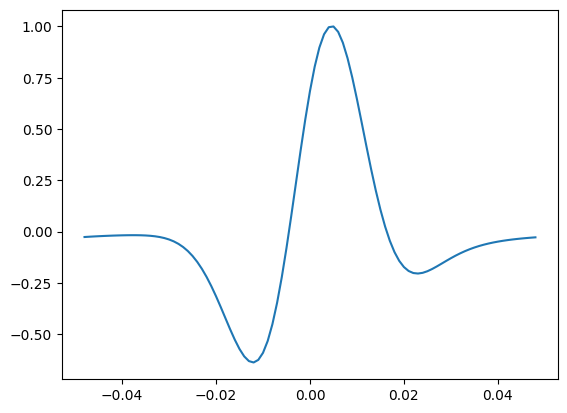

In [80]:
w_generalised,t=bg.filters.generalized(
    duration=0.096,
    dt=0.001,
    f=25,
    u=1.5
)
plt.plot(t,w_generalised)

In [87]:
w_0,t=bg.filters.generalized(
    duration=0.096,
    dt=0.001,
    f=25,
    u=2
)

w_rotat=bg.filters.rotate_phase(w_0, -0.6 )
# w_rotat = bg.filters.rotate_phase(w_0, -0.6)  # radians
print("The shape of the generazide wavelet:",w_generalise.shape)
print("The shape of the rotated phase wavelet:",w_rotat)

The shape of the generazide wavelet: (97,)
The shape of the rotated phase wavelet: [-3.05826735e-05  1.16584375e-03  2.37264072e-03  3.60752020e-03
  4.88695750e-03  6.22599552e-03  7.63753894e-03  9.13099673e-03
  1.07100878e-02  1.23695896e-02  1.40907900e-02  1.58354153e-02
  1.75378644e-02  1.90956979e-02  2.03585399e-02  2.11158419e-02
  2.10843616e-02  1.98966968e-02  1.70927583e-02  1.21166148e-02
  4.32159430e-03 -7.01321729e-03 -2.26520258e-02 -4.33544294e-02
 -6.98092146e-02 -1.02550281e-01 -1.41857544e-01 -1.87648551e-01
 -2.39369685e-01 -2.95898743e-01 -3.55472956e-01 -4.15657541e-01
 -4.73369176e-01 -5.24965975e-01 -5.66410428e-01 -5.93504645e-01
 -6.02188498e-01 -5.88882000e-01 -5.50844478e-01 -4.86516398e-01
 -3.95806105e-01 -2.80284533e-01 -1.43256418e-01  1.03132311e-02
  1.74024667e-01  3.40411853e-01  5.01428141e-01  6.49008763e-01
  7.75659035e-01  8.75012195e-01  9.42302373e-01  9.74706337e-01
  9.71521501e-01  9.34165270e-01  8.66000052e-01  7.72006455e-01
  6.583

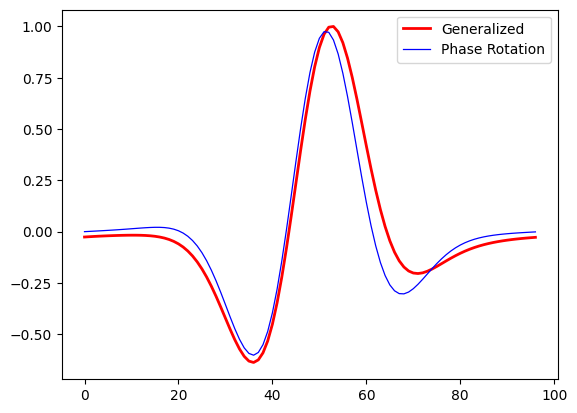

In [97]:
plt.plot(w_generalise,label="Generalized",color="red",lw=2)
plt.plot(w_rotat,label="Phase Rotation",color="blue",lw=0.9)
plt.legend()

Text(0.5, 1.0, 'Full range of the wavelet')

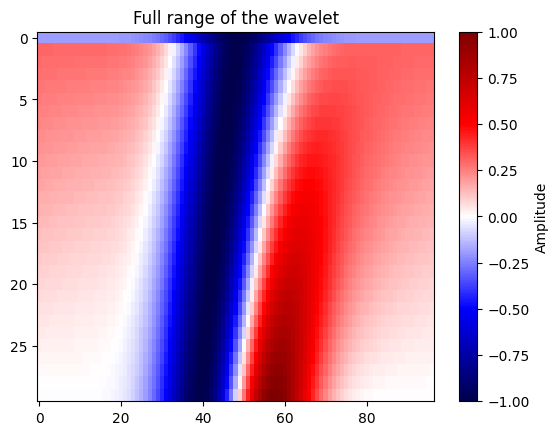

In [107]:
w_generalised_full_range,t=bg.filters.generalized(
    duration=0.096,
    dt=0.001,
    f=25,
    u=np.linspace(0,1,30)
)
w_generalised_full_range.shape
plt.imshow(w_generalised_full_range,aspect="auto",cmap="seismic")
plt.colorbar(label="Amplitude")
plt.title("Full range of the wavelet")

(30, 97)


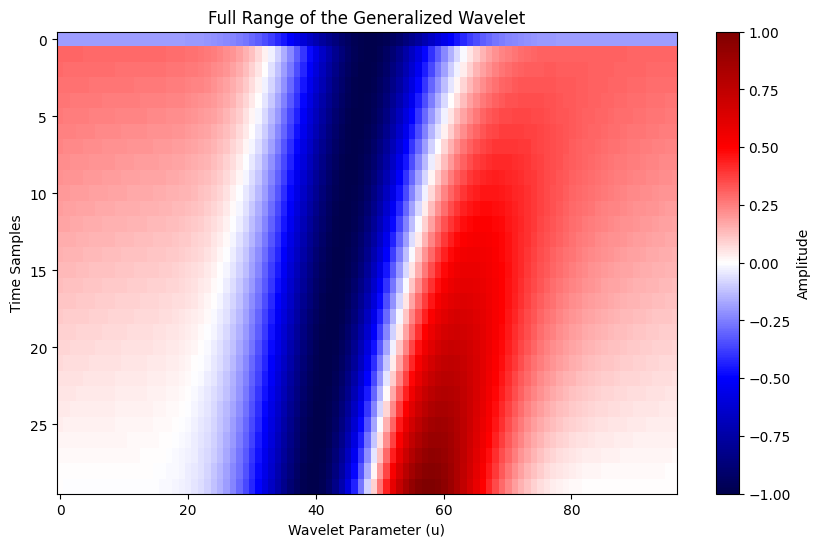

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import bruges as bg

w_generalised_full_range, t = bg.filters.generalized(
    duration=0.096,
    dt=0.001,
    f=25,
    u=np.linspace(0, 1, 30)
)

print(w_generalised_full_range.shape)

plt.figure(figsize=(10,6))
plt.imshow(w_generalised_full_range, aspect="auto", cmap="seismic")
plt.colorbar(label="Amplitude")
plt.title("Full Range of the Generalized Wavelet")
plt.xlabel("Wavelet Parameter (u)")
plt.ylabel("Time Samples")
plt.show()

## Comparison of Seismic Wavelets (Bruges)

| Wavelet | Type | Key Parameter | Spectral Shape | Main Use in Geophysics |
|--------|------|--------------|---------------|------------------------|
| **Ricker** | Zero-phase symmetric | Dominant frequency $f$ | Gaussian spectrum | Most common synthetic seismic modeling |
| **Ormsby** | Bandpass wavelet | $[f_1, f_2, f_3, f_4]$ | Trapezoidal spectrum | Realistic seismic bandwidth modeling |
| **Klauder** | Sweep autocorrelation | $[f_{\text{start}}, f_{\text{end}}]$ | Wide-band sweep | Vibroseis acquisition modeling |
| **Berlage** | Minimum-phase | $f, n, \alpha, \phi$ | Asymmetric spectrum | Marine airgun seismic |
| **Sinc** | Ideal filter wavelet | $f$ | Rectangular spectrum | Signal processing experiments |
| **Gabor** | Gaussian-modulated sinusoid | $f$ | Narrowband Gaussian | Time-frequency analysis |
| **Gaussian** | Pure Gaussian pulse | Width parameter | Gaussian spectrum | Mathematical / theoretical studies |
| **Generalized** | Fractional Gaussian derivative | $f, u$ | Variable spectrum | Flexible wavelet modeling |

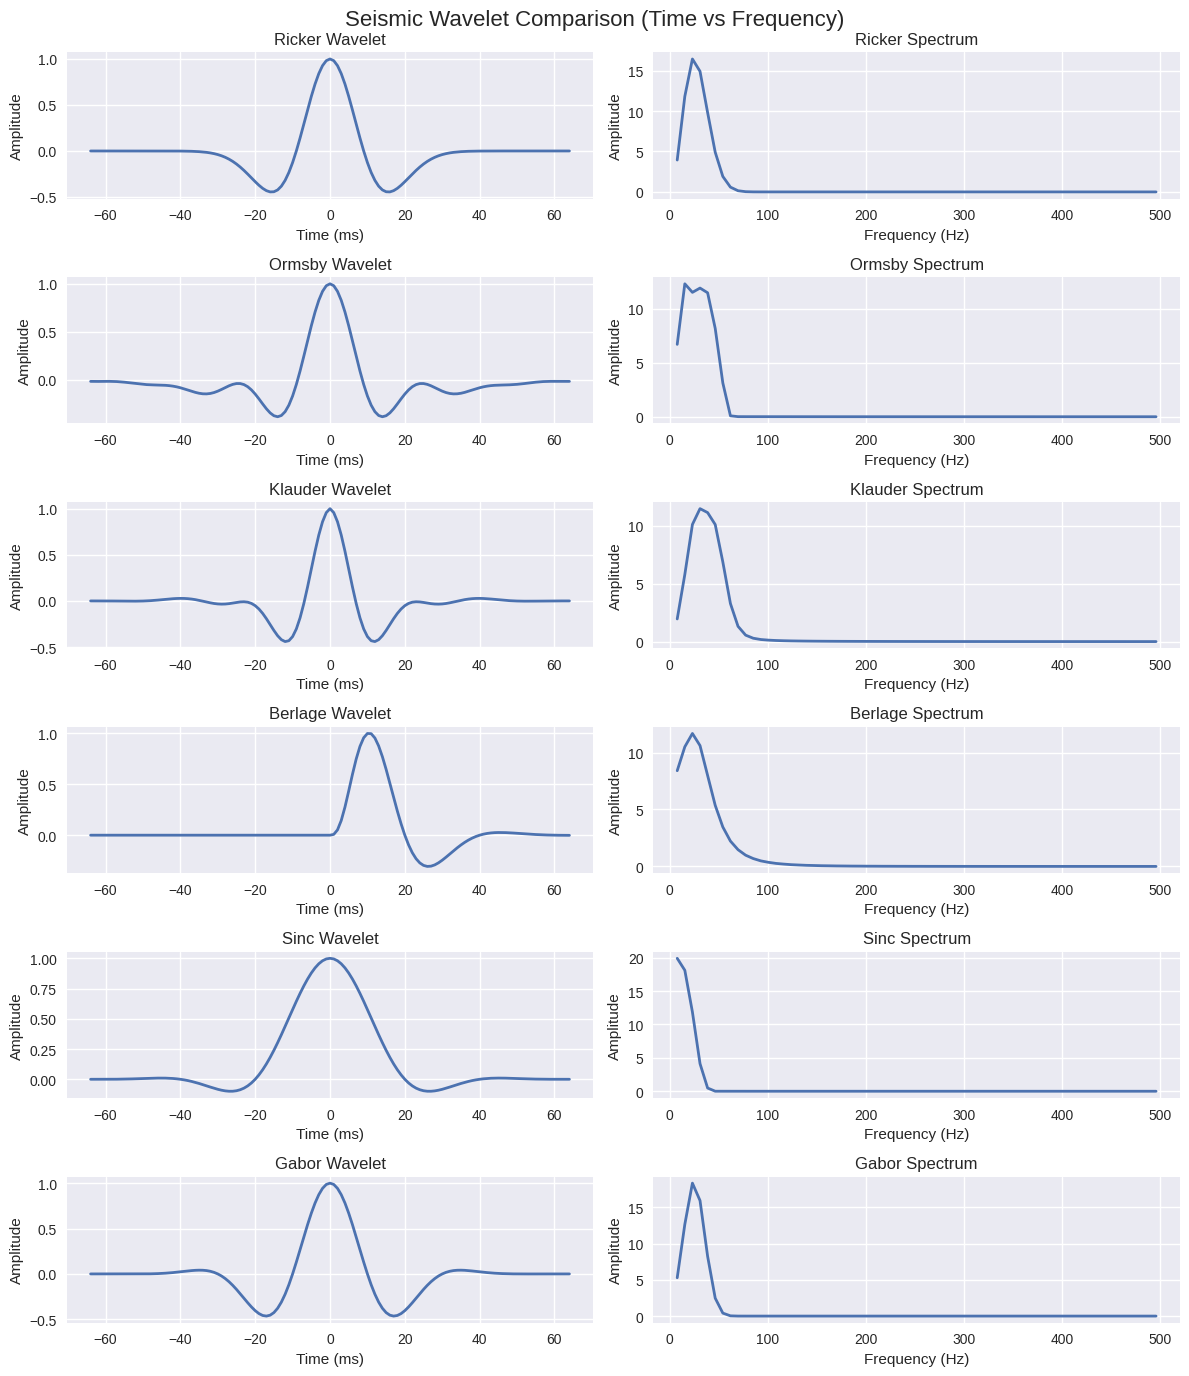

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import bruges as bg
from scipy.fft import fft, fftfreq

# Common parameters
duration = 0.128
dt = 0.001
f = 25
plt.style.use("seaborn-v0_8")
# Generate wavelets
wavelets = {
    "Ricker": bg.filters.ricker(duration=duration, dt=dt, f=f),
    "Ormsby": bg.filters.ormsby(duration=duration, dt=dt, f=[5,10,40,60]),
    "Klauder": bg.filters.klauder(duration=duration, dt=dt, f=[10,60]),
    "Berlage": bg.filters.berlage(duration=duration, dt=dt, f=f),
    "Sinc": bg.filters.sinc(duration=duration, dt=dt, f=f),
    "Gabor": bg.filters.gabor(duration=duration, dt=dt, f=f),
}

n_wavelets = len(wavelets)

fig, axes = plt.subplots(n_wavelets, 2, figsize=(12, 14))

for i, (name, (w, t)) in enumerate(wavelets.items()):

    # Normalize wavelet
    w = w / np.max(np.abs(w))

    # -------- Time domain --------
    axes[i,0].plot(t*1000, w, lw=2)
    axes[i,0].set_title(f"{name} Wavelet")
    axes[i,0].set_xlabel("Time (ms)")
    axes[i,0].set_ylabel("Amplitude")
    axes[i,0].grid(True)

    # -------- Frequency domain --------
    W = np.abs(fft(w))
    freq = fftfreq(len(w), dt)

    pos = freq > 0
    axes[i,1].plot(freq[pos], W[pos], lw=2)
    axes[i,1].set_title(f"{name} Spectrum")
    axes[i,1].set_xlabel("Frequency (Hz)")
    axes[i,1].set_ylabel("Amplitude")
    axes[i,1].grid(True)

plt.suptitle("Seismic Wavelet Comparison (Time vs Frequency)", fontsize=16)
plt.tight_layout()
plt.show()

[seismic_wavelets] Generating figure for 6 wavelets …
[seismic_wavelets] Saved → /home/ashraf/Desktop/100-Days-of-Python-for-Oil-Gas-Subsurface-Analytics-Well-log/Day-04-06/seismic_wavelet_analysis.pdf


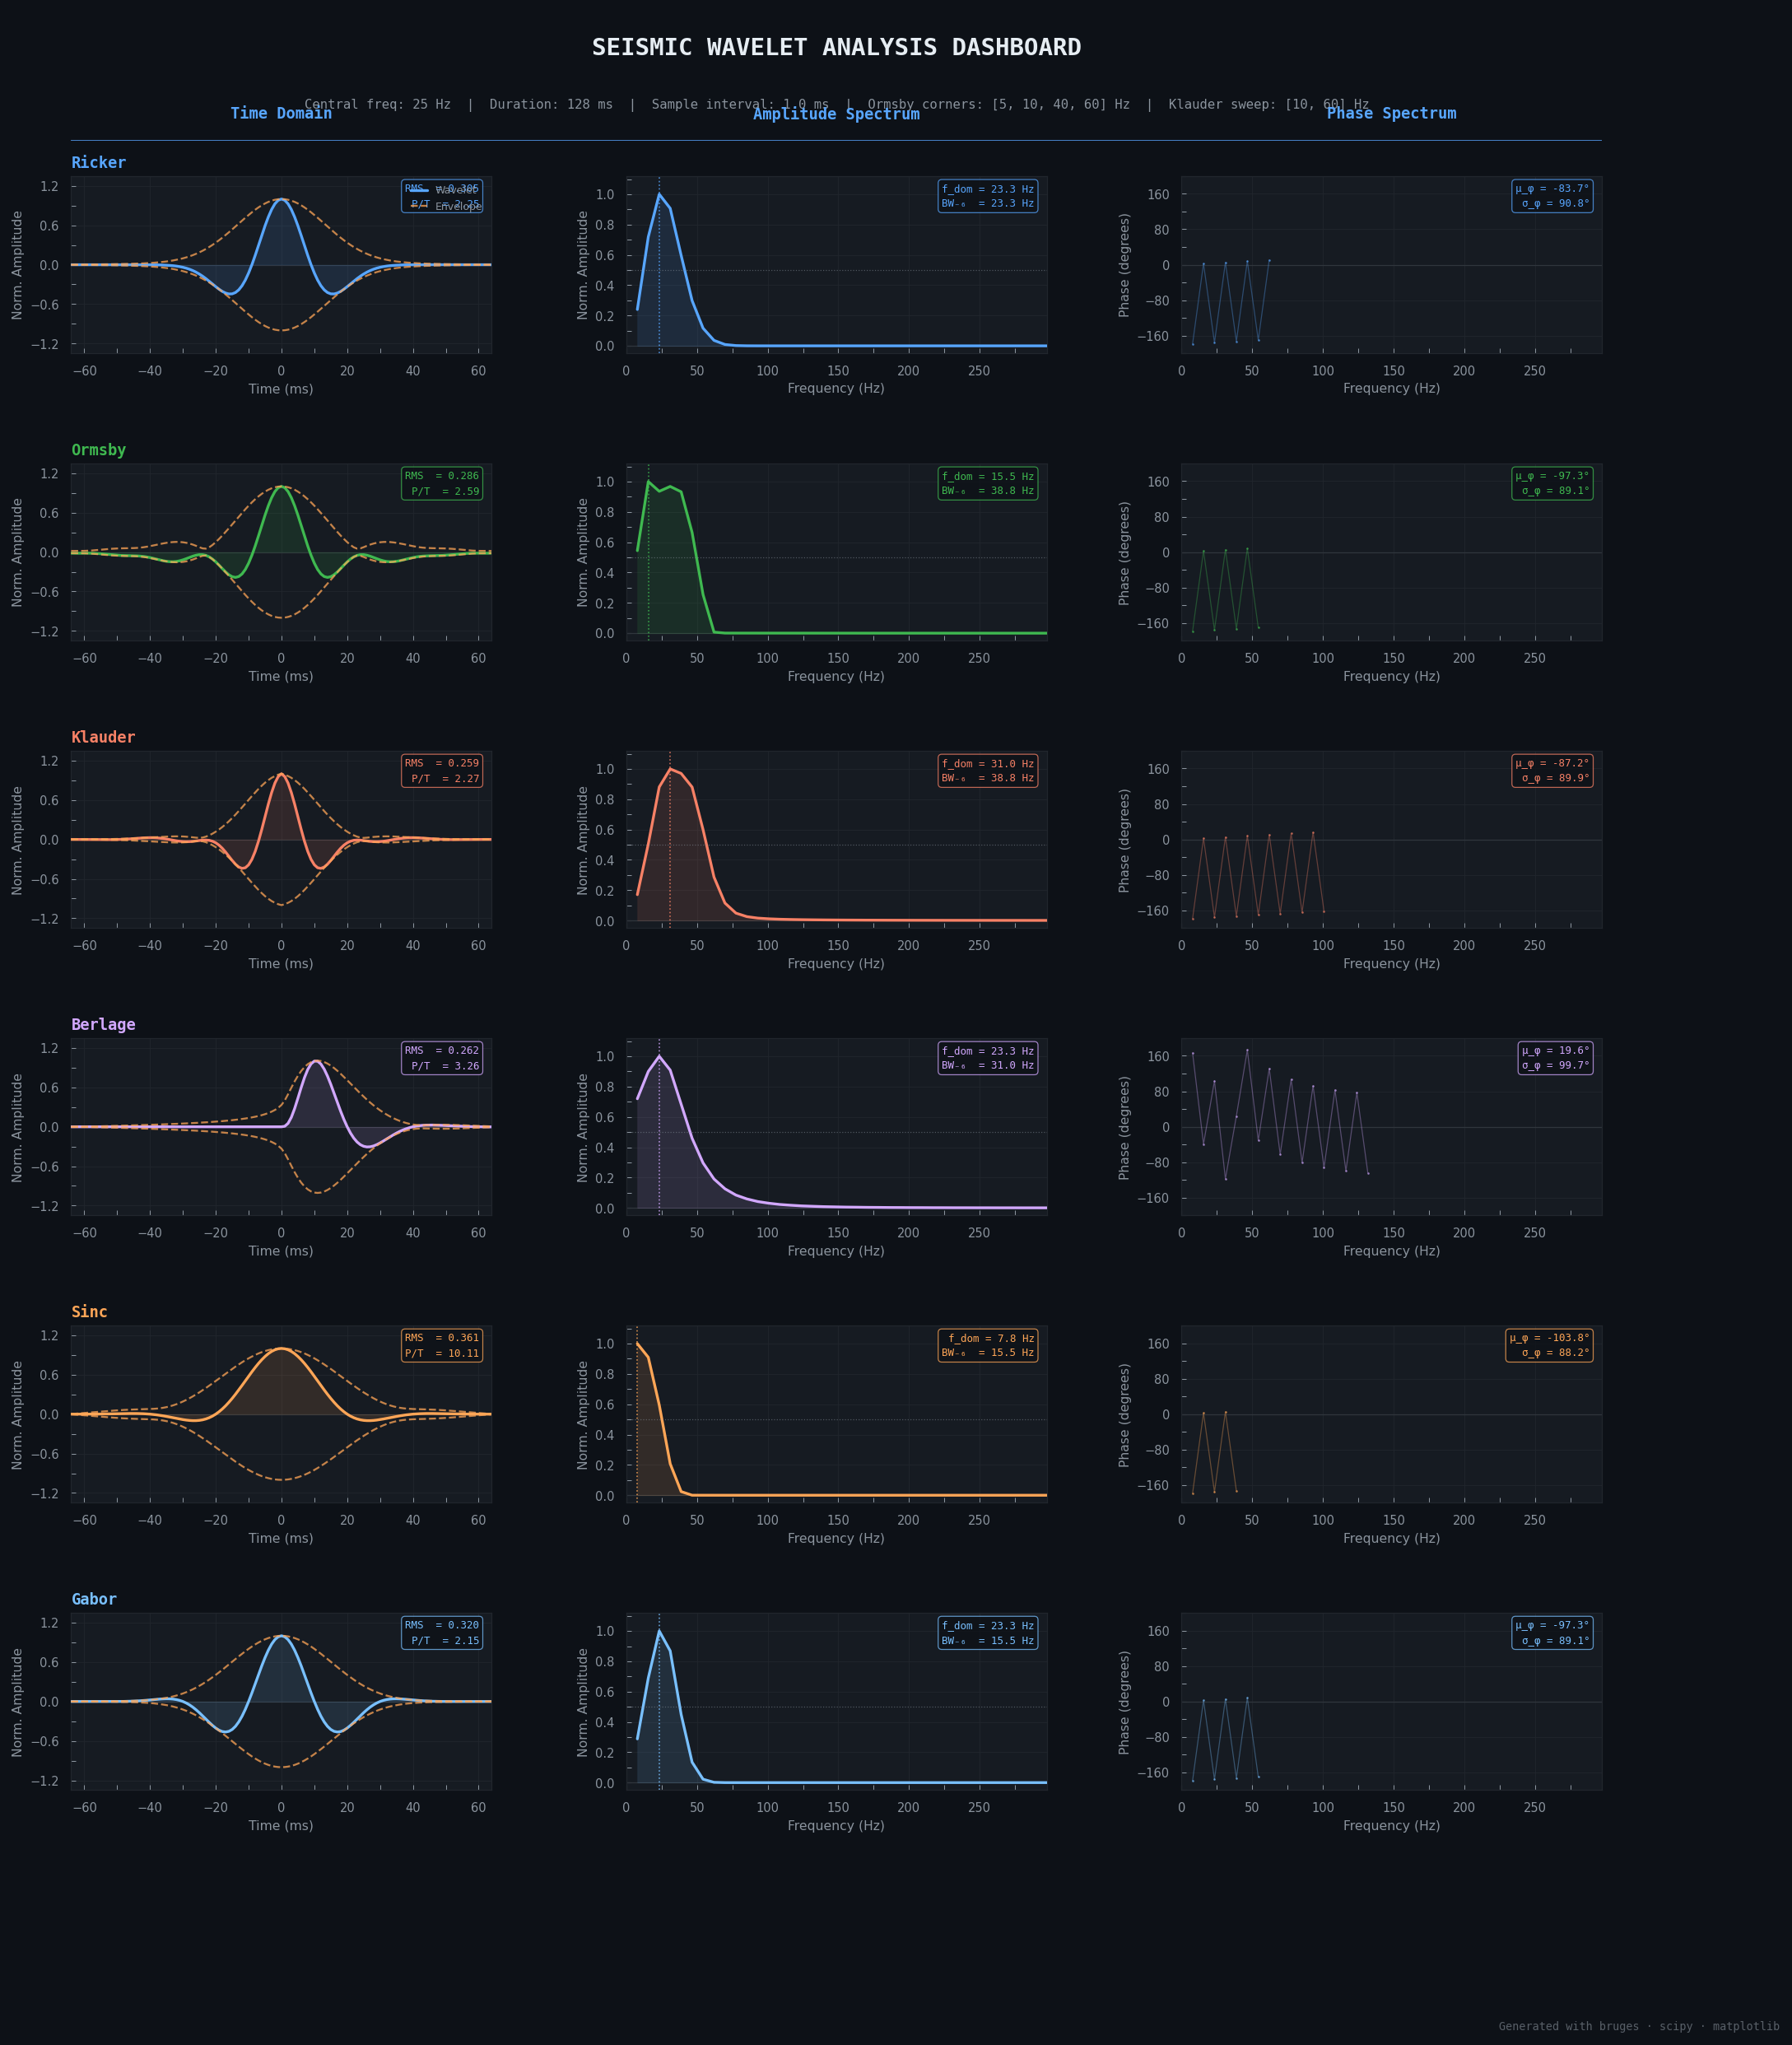

In [116]:
"""
seismic_wavelets.py
===================
Professional seismic wavelet analysis dashboard.

Generates time-domain waveforms, amplitude spectra, phase spectra, and
instantaneous attributes for six standard seismic wavelets, then exports
a publication-ready PDF figure.

Dependencies
------------
    pip install bruges scipy matplotlib numpy

Usage
-----
    python seismic_wavelets.py
"""

from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
from scipy.fft import fft, fftfreq
from scipy.signal import hilbert
import bruges as bg

warnings.filterwarnings("ignore", category=UserWarning)

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

@dataclass
class WaveletConfig:
    """Central configuration for wavelet generation and display."""

    duration: float = 0.128        # seconds
    dt: float = 0.001              # seconds
    f_central: float = 25.0        # Hz  – dominant frequency

    # Ormsby corner frequencies  [f1, f2, f3, f4]
    ormsby_f: list = field(default_factory=lambda: [5, 10, 40, 60])

    # Klauder sweep band  [f_low, f_high]
    klauder_f: list = field(default_factory=lambda: [10, 60])

    output_file: str = "seismic_wavelet_analysis.pdf"
    dpi: int = 150


# ---------------------------------------------------------------------------
# Colour & style definitions
# ---------------------------------------------------------------------------

PALETTE = {
    "bg_fig":      "#0d1117",
    "bg_panel":    "#161b22",
    "bg_header":   "#1c2128",
    "grid":        "#21262d",
    "tick":        "#8b949e",
    "text_main":   "#e6edf3",
    "text_sub":    "#8b949e",
    "accent":      "#58a6ff",
    "positive":    "#3fb950",
    "negative":    "#f85149",
    "zero_line":   "#30363d",
    "envelope":    "#ffa657",
}

# One accent colour per wavelet row
ROW_COLOURS = [
    "#58a6ff",   # Ricker   – steel blue
    "#3fb950",   # Ormsby   – emerald
    "#f78166",   # Klauder  – coral
    "#d2a8ff",   # Berlage  – lavender
    "#ffa657",   # Sinc     – amber
    "#79c0ff",   # Gabor    – sky
]

FONT_MONO  = "DejaVu Sans Mono"
FONT_SANS  = "DejaVu Sans"
LW_MAIN    = 1.6
LW_ENV     = 1.1
LW_ZERO    = 0.6
ALPHA_FILL = 0.12
ALPHA_ENV  = 0.75


# ---------------------------------------------------------------------------
# Wavelet generation
# ---------------------------------------------------------------------------

WaveletDict = Dict[str, Tuple[np.ndarray, np.ndarray]]


def build_wavelets(cfg: WaveletConfig) -> WaveletDict:
    """Return a dict of {name: (amplitude_array, time_array)} pairs."""

    common = dict(duration=cfg.duration, dt=cfg.dt)

    raw: WaveletDict = {
        "Ricker":  bg.filters.ricker (**common, f=cfg.f_central),
        "Ormsby":  bg.filters.ormsby (**common, f=cfg.ormsby_f),
        "Klauder": bg.filters.klauder(**common, f=cfg.klauder_f),
        "Berlage": bg.filters.berlage(**common, f=cfg.f_central),
        "Sinc":    bg.filters.sinc   (**common, f=cfg.f_central),
        "Gabor":   bg.filters.gabor  (**common, f=cfg.f_central),
    }

    # Normalise each wavelet to unit peak amplitude
    normalised: WaveletDict = {}
    for name, (w, t) in raw.items():
        peak = np.max(np.abs(w))
        normalised[name] = (w / peak if peak > 0 else w, t)

    return normalised


# ---------------------------------------------------------------------------
# Signal analysis helpers
# ---------------------------------------------------------------------------

def compute_spectrum(w: np.ndarray, dt: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (positive frequencies, amplitude spectrum, phase spectrum)."""
    n    = len(w)
    W    = fft(w, n=n)
    freq = fftfreq(n, dt)

    pos   = freq > 0
    amp   = np.abs(W)[pos]
    phase = np.angle(W)[pos]          # radians

    # Normalise amplitude to 0-1
    peak = amp.max()
    if peak > 0:
        amp = amp / peak

    return freq[pos], amp, phase


def dominant_frequency(freq: np.ndarray, amp: np.ndarray) -> float:
    """Frequency at peak amplitude."""
    return freq[np.argmax(amp)]


def bandwidth(freq: np.ndarray, amp: np.ndarray, db: float = -6.0) -> float:
    """Bandwidth at a given dB level below peak amplitude (negative dB)."""
    threshold = 10 ** (db / 20.0)   # linear threshold
    above = freq[amp >= threshold]
    return float(above[-1] - above[0]) if len(above) > 1 else 0.0


def rms_amplitude(w: np.ndarray) -> float:
    return float(np.sqrt(np.mean(w ** 2)))


def peak_to_trough_ratio(w: np.ndarray) -> float:
    peak  = np.max(w)
    trough = np.abs(np.min(w))
    return float(peak / trough) if trough > 0 else float("inf")


# ---------------------------------------------------------------------------
# Plot helpers
# ---------------------------------------------------------------------------

def _apply_panel_style(ax: plt.Axes, colour: str) -> None:
    ax.set_facecolor(PALETTE["bg_panel"])
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["grid"])
        spine.set_linewidth(0.6)
    ax.tick_params(
        colors=PALETTE["tick"],
        labelsize=7,
        length=3,
        width=0.5,
        direction="in",
        which="both",
    )
    ax.xaxis.label.set_color(PALETTE["text_sub"])
    ax.yaxis.label.set_color(PALETTE["text_sub"])
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(which="major", color=PALETTE["grid"], linewidth=0.4, linestyle="-")
    ax.grid(which="minor", color=PALETTE["grid"], linewidth=0.2, linestyle=":")
    # Thin accent line on the top edge
    ax.axhline(0, color=PALETTE["zero_line"], linewidth=LW_ZERO, zorder=1)


def _label(ax: plt.Axes, xlabel: str, ylabel: str) -> None:
    ax.set_xlabel(xlabel, fontsize=7.5, labelpad=3, fontfamily=FONT_SANS)
    ax.set_ylabel(ylabel, fontsize=7.5, labelpad=3, fontfamily=FONT_SANS)


def _stat_box(ax: plt.Axes, lines: list[str], colour: str) -> None:
    """Overlay a small statistics annotation box in the top-right corner."""
    text = "\n".join(lines)
    ax.text(
        0.97, 0.96, text,
        transform=ax.transAxes,
        fontsize=6.0,
        fontfamily=FONT_MONO,
        color=colour,
        ha="right", va="top",
        linespacing=1.55,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=PALETTE["bg_fig"],
            edgecolor=colour,
            alpha=0.75,
            linewidth=0.6,
        ),
    )


# ---------------------------------------------------------------------------
# Main figure
# ---------------------------------------------------------------------------

def build_figure(wavelets: WaveletDict, cfg: WaveletConfig) -> plt.Figure:
    """Construct and return the full analysis figure."""

    n_rows = len(wavelets)
    n_cols = 3    # time | amplitude spectrum | phase spectrum

    mpl.rcParams.update({
        "font.family":       FONT_SANS,
        "text.color":        PALETTE["text_main"],
        "axes.labelcolor":   PALETTE["text_sub"],
        "xtick.color":       PALETTE["tick"],
        "ytick.color":       PALETTE["tick"],
        "figure.facecolor":  PALETTE["bg_fig"],
        "savefig.facecolor": PALETTE["bg_fig"],
    })

    fig = plt.figure(figsize=(16, 2.85 * n_rows + 1.6), dpi=cfg.dpi)

    # ---- outer GridSpec: header row + data rows --------------------------
    outer = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[0.08, 1],
        hspace=0.04,
    )

    # ---- header panel ----------------------------------------------------
    ax_hdr = fig.add_subplot(outer[0])
    ax_hdr.set_facecolor(PALETTE["bg_header"])
    ax_hdr.set_axis_off()

    ax_hdr.text(
        0.5, 0.72,
        "SEISMIC WAVELET ANALYSIS DASHBOARD",
        transform=ax_hdr.transAxes,
        fontsize=14, fontweight="bold",
        fontfamily=FONT_MONO,
        color=PALETTE["text_main"],
        ha="center", va="center",
    )
    meta = (
        f"Central freq: {cfg.f_central:.0f} Hz  |  "
        f"Duration: {cfg.duration*1e3:.0f} ms  |  "
        f"Sample interval: {cfg.dt*1e3:.1f} ms  |  "
        f"Ormsby corners: {cfg.ormsby_f} Hz  |  "
        f"Klauder sweep: {cfg.klauder_f} Hz"
    )
    ax_hdr.text(
        0.5, 0.28, meta,
        transform=ax_hdr.transAxes,
        fontsize=7.5,
        fontfamily=FONT_MONO,
        color=PALETTE["text_sub"],
        ha="center", va="center",
    )
    # Thin separator line
    ax_hdr.axhline(0, color=PALETTE["accent"], linewidth=1.2)

    # ---- column header row -----------------------------------------------
    inner = gridspec.GridSpecFromSubplotSpec(
        n_rows, n_cols,
        subplot_spec=outer[1],
        wspace=0.32,
        hspace=0.62,
    )

    col_titles = ["Time Domain", "Amplitude Spectrum", "Phase Spectrum"]

    for j, title in enumerate(col_titles):
        ax_ct = fig.add_subplot(inner[0, j])
        ax_ct.set_facecolor(PALETTE["bg_fig"])
        ax_ct.set_axis_off()
        ax_ct.text(
            0.5, 1.35, title,
            transform=ax_ct.transAxes,
            fontsize=9, fontweight="bold",
            fontfamily=FONT_MONO,
            color=PALETTE["accent"],
            ha="center", va="center",
        )

    # ---- per-wavelet rows -----------------------------------------------
    for i, (name, (w, t)) in enumerate(wavelets.items()):
        colour = ROW_COLOURS[i % len(ROW_COLOURS)]

        t_ms = t * 1000
        freq, amp, phase = compute_spectrum(w, cfg.dt)

        # ---- [col 0] Time domain ----------------------------------------
        ax_t = fig.add_subplot(inner[i, 0])
        _apply_panel_style(ax_t, colour)

        # Envelope (instantaneous amplitude)
        envelope = np.abs(hilbert(w))
        ax_t.fill_between(t_ms, w, alpha=ALPHA_FILL, color=colour, zorder=2)
        ax_t.plot(t_ms, w, lw=LW_MAIN, color=colour, zorder=3, label="Wavelet")
        ax_t.plot(t_ms, envelope,  lw=LW_ENV, color=PALETTE["envelope"],
                  alpha=ALPHA_ENV, ls="--", zorder=3, label="Envelope")
        ax_t.plot(t_ms, -envelope, lw=LW_ENV, color=PALETTE["envelope"],
                  alpha=ALPHA_ENV, ls="--", zorder=3)

        ax_t.set_xlim(t_ms[0], t_ms[-1])
        ax_t.set_ylim(-1.35, 1.35)
        _label(ax_t, "Time (ms)", "Norm. Amplitude")
        ax_t.yaxis.set_major_locator(MaxNLocator(5, symmetric=True))

        # Row label on left spine
        ax_t.set_title(
            name,
            fontsize=9, fontweight="bold",
            fontfamily=FONT_MONO,
            color=colour, pad=5, loc="left",
        )

        stats_t = [
            f"RMS  = {rms_amplitude(w):.3f}",
            f"P/T  = {peak_to_trough_ratio(w):.2f}",
        ]
        _stat_box(ax_t, stats_t, colour)

        if i == 0:
            ax_t.legend(
                fontsize=6,
                framealpha=0.35,
                facecolor=PALETTE["bg_fig"],
                edgecolor=PALETTE["grid"],
                labelcolor=PALETTE["text_sub"],
                loc="upper right",
                handlelength=1.6,
            )

        # ---- [col 1] Amplitude spectrum ----------------------------------
        ax_f = fig.add_subplot(inner[i, 1])
        _apply_panel_style(ax_f, colour)

        f_dom = dominant_frequency(freq, amp)
        bw_6db = bandwidth(freq, amp, db=-6.0)

        ax_f.fill_between(freq, amp, alpha=ALPHA_FILL, color=colour, zorder=2)
        ax_f.plot(freq, amp, lw=LW_MAIN, color=colour, zorder=3)

        # Mark dominant frequency
        ax_f.axvline(f_dom, color=colour, lw=0.8, ls=":", alpha=0.8, zorder=4)
        ax_f.axhline(10 ** (-6.0 / 20.0), color=PALETTE["text_sub"],
                     lw=0.6, ls=":", alpha=0.5, zorder=4)

        ax_f.set_xlim(0, freq[-1] * 0.6)
        ax_f.set_ylim(-0.05, 1.12)
        _label(ax_f, "Frequency (Hz)", "Norm. Amplitude")

        stats_f = [
            f"f_dom = {f_dom:.1f} Hz",
            f"BW₋₆  = {bw_6db:.1f} Hz",
        ]
        _stat_box(ax_f, stats_f, colour)

        # ---- [col 2] Phase spectrum --------------------------------------
        ax_p = fig.add_subplot(inner[i, 2])
        _apply_panel_style(ax_p, colour)

        # Only show phase where amplitude is meaningful (> 1 % of peak)
        mask = amp > 0.01
        ax_p.scatter(
            freq[mask], np.degrees(phase[mask]),
            s=1.5, color=colour, alpha=0.7, linewidths=0,
        )
        ax_p.plot(
            freq[mask], np.degrees(phase[mask]),
            lw=0.6, color=colour, alpha=0.35,
        )

        ax_p.set_xlim(0, freq[-1] * 0.6)
        ax_p.set_ylim(-200, 200)
        ax_p.yaxis.set_major_locator(MaxNLocator(5, symmetric=True))
        _label(ax_p, "Frequency (Hz)", "Phase (degrees)")

        # Mean phase
        mean_phase = float(np.degrees(np.mean(phase[mask])))
        std_phase  = float(np.degrees(np.std(phase[mask])))
        stats_p = [
            f"μ_φ = {mean_phase:.1f}°",
            f"σ_φ = {std_phase:.1f}°",
        ]
        _stat_box(ax_p, stats_p, colour)

    # ---- footer ----------------------------------------------------------
    fig.text(
        0.99, 0.005,
        "Generated with bruges · scipy · matplotlib",
        ha="right", va="bottom",
        fontsize=6.5, fontfamily=FONT_MONO,
        color=PALETTE["text_sub"], alpha=0.6,
    )

    return fig


# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

def main() -> None:
    cfg      = WaveletConfig()
    wavelets = build_wavelets(cfg)

    print(f"[seismic_wavelets] Generating figure for {len(wavelets)} wavelets …")
    fig = build_figure(wavelets, cfg)

    out = Path(cfg.output_file)
    fig.savefig(out, dpi=cfg.dpi, bbox_inches="tight")
    print(f"[seismic_wavelets] Saved → {out.resolve()}")

    plt.show()


if __name__ == "__main__":
    main()